# Process data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('bike_sales_100k.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Sale_ID          100000 non-null  int64  
 1   Date             100000 non-null  object 
 2   Customer_ID      100000 non-null  int64  
 3   Bike_Model       100000 non-null  object 
 4   Price            100000 non-null  float64
 5   Quantity         100000 non-null  int64  
 6   Store_Location   100000 non-null  object 
 7   Salesperson_ID   100000 non-null  int64  
 8   Payment_Method   100000 non-null  object 
 9   Customer_Age     100000 non-null  int64  
 10  Customer_Gender  100000 non-null  object 
dtypes: float64(1), int64(5), object(5)
memory usage: 8.4+ MB


In [3]:
df.head(5)

,Sale_ID,Date,Customer_ID,Bike_Model,Price,Quantity,Store_Location,Salesperson_ID,Payment_Method,Customer_Age,Customer_Gender
0,1,11-07-2022,9390,Cruiser,318.32,1,Philadelphia,589,Apple Pay,70,Female
1,2,03-05-2024,3374,Hybrid Bike,3093.47,4,Chicago,390,Apple Pay,37,Male
2,3,01-09-2022,2689,Folding Bike,4247.99,3,San Antonio,338,PayPal,59,Female
3,4,28-09-2022,3797,Mountain Bike,1722.01,3,San Antonio,352,Apple Pay,19,Male
4,5,05-01-2021,1633,BMX,3941.44,3,Philadelphia,580,PayPal,67,Female


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isna().sum()

Sale_ID            0
Date               0
Customer_ID        0
Bike_Model         0
Price              0
Quantity           0
Store_Location     0
Salesperson_ID     0
Payment_Method     0
Customer_Age       0
Customer_Gender    0
dtype: int64

In [6]:
df.nunique()

Sale_ID            100000
Date                 1727
Customer_ID          9000
Bike_Model              7
Price               90336
Quantity                5
Store_Location          7
Salesperson_ID        900
Payment_Method          6
Customer_Age           53
Customer_Gender         2
dtype: int64

In [7]:
df.describe()

,Sale_ID,Customer_ID,Price,Quantity,Salesperson_ID,Customer_Age
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,5495.450720,2598.182340,2.997110,549.906300,44.043410
std,28867.657797,2598.873948,1384.943133,1.414235,259.679221,15.313761
min,1.000000,1000.000000,200.010000,1.000000,100.000000,18.000000
25%,25000.750000,3249.000000,1399.787500,2.000000,324.000000,31.000000
50%,50000.500000,5491.000000,2598.575000,3.000000,550.000000,44.000000
75%,75000.250000,7738.000000,3795.982500,4.000000,775.000000,57.000000
max,100000.000000,9999.000000,4999.810000,5.000000,999.000000,70.000000


In [8]:
categorical_columns = ['Bike_Model','Store_Location','Payment_Method','Customer_Gender']

print('Unique data for categorical columns')
for col in categorical_columns:
    
    print(f"Category in {col} is : {df[col].unique()}")

Unique data for categorical columns
Category in Bike_Model is : ['Cruiser' 'Hybrid Bike' 'Folding Bike' 'Mountain Bike' 'BMX' 'Road Bike'
 'Electric Bike']
Category in Store_Location is : ['Philadelphia' 'Chicago' 'San Antonio' 'Los Angeles' 'Houston' 'New York'
 'Phoenix']
Category in Payment_Method is : ['Apple Pay' 'PayPal' 'Google Pay' 'Debit Card' 'Credit Card' 'Cash']
Category in Customer_Gender is : ['Female' 'Male']


In [9]:
print(df.head())

   Sale_ID        Date  Customer_ID     Bike_Model    Price  Quantity  \
0        1  11-07-2022         9390        Cruiser   318.32         1   
1        2  03-05-2024         3374    Hybrid Bike  3093.47         4   
2        3  01-09-2022         2689   Folding Bike  4247.99         3   
3        4  28-09-2022         3797  Mountain Bike  1722.01         3   
4        5  05-01-2021         1633            BMX  3941.44         3   

  Store_Location  Salesperson_ID Payment_Method  Customer_Age Customer_Gender  
0   Philadelphia             589      Apple Pay            70          Female  
1        Chicago             390      Apple Pay            37            Male  
2    San Antonio             338         PayPal            59          Female  
3    San Antonio             352      Apple Pay            19            Male  
4   Philadelphia             580         PayPal            67          Female  


In [10]:
df['Total_Revenue'] = df['Price']*df['Quantity']

In [11]:
df.head()

,Sale_ID,Date,Customer_ID,Bike_Model,Price,Quantity,Store_Location,Salesperson_ID,Payment_Method,Customer_Age,Customer_Gender,Total_Revenue
0,1,11-07-2022,9390,Cruiser,318.32,1,Philadelphia,589,Apple Pay,70,Female,318.32
1,2,03-05-2024,3374,Hybrid Bike,3093.47,4,Chicago,390,Apple Pay,37,Male,12373.88
2,3,01-09-2022,2689,Folding Bike,4247.99,3,San Antonio,338,PayPal,59,Female,12743.97
3,4,28-09-2022,3797,Mountain Bike,1722.01,3,San Antonio,352,Apple Pay,19,Male,5166.03
4,5,05-01-2021,1633,BMX,3941.44,3,Philadelphia,580,PayPal,67,Female,11824.32


# EDA

## Question 1. Which bike models are the top performers by revenue?

<Axes: title={'center': ' Total Revenue per model'}, ylabel='Bike_Model'>

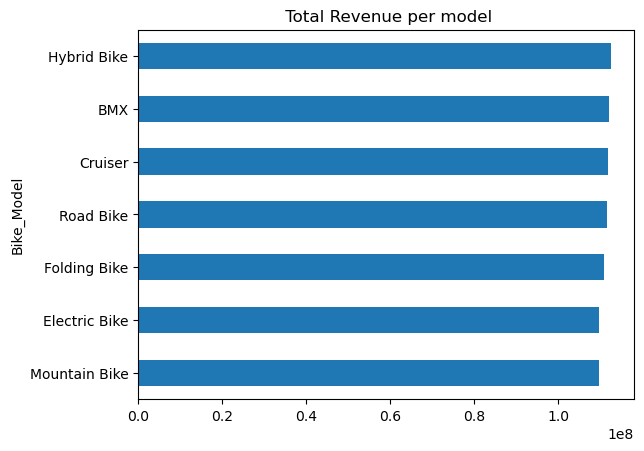

In [30]:
#Total Revenue per bike model
df.groupby('Bike_Model')['Total_Revenue'].sum().sort_values().plot(kind='barh', title = ' Total Revenue per model')


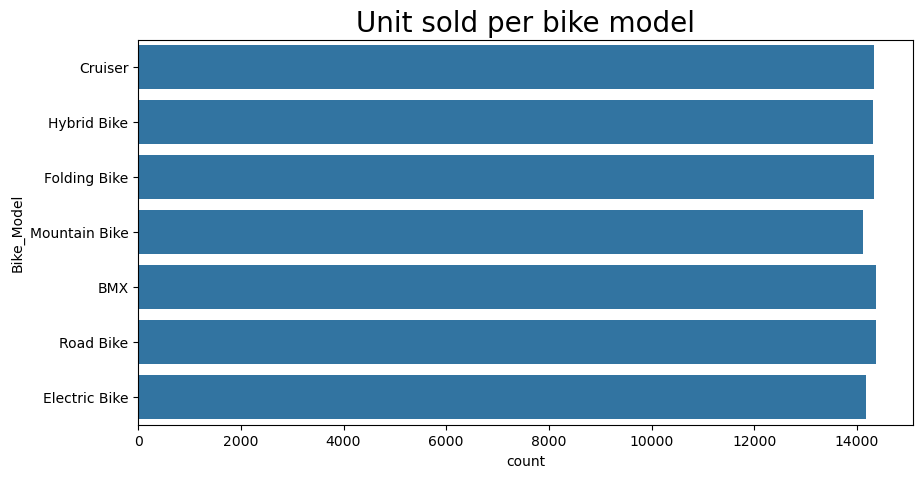

In [15]:
#Unit sold per bike model
plt.figure(figsize = (10, 5))
sns.countplot(y = df.Bike_Model)
plt.title("Unit sold per bike model", fontsize = 20)
plt.show()

<Axes: title={'center': ' Average price per model'}, ylabel='Bike_Model'>

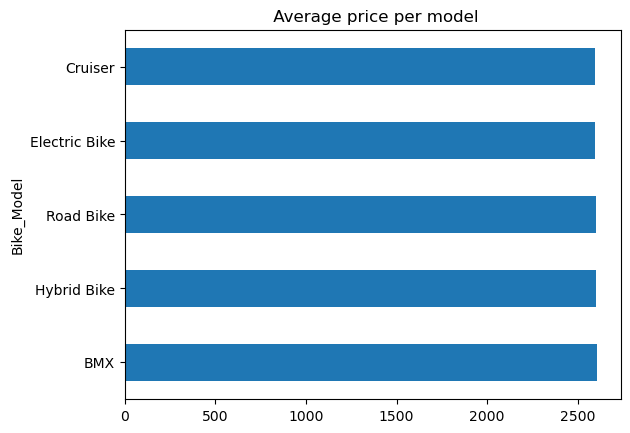

In [16]:
#Average price per model
df.groupby('Bike_Model')['Price'].mean().nlargest().plot(kind='barh',
                                                           title = ' Average price per model')

## Question 2. What are the monthly/quarterly sales trends?

In [46]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df['Month_Year'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

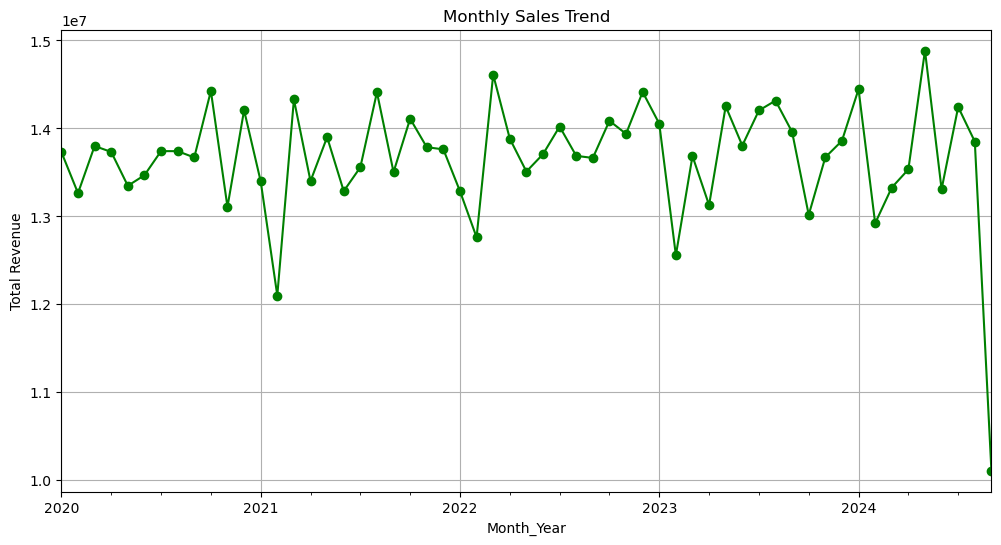

In [45]:
monthly_trend = df.groupby('Month_Year')['Total_Revenue'].sum()

plt.figure(figsize=(12, 6))
monthly_trend.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.show()

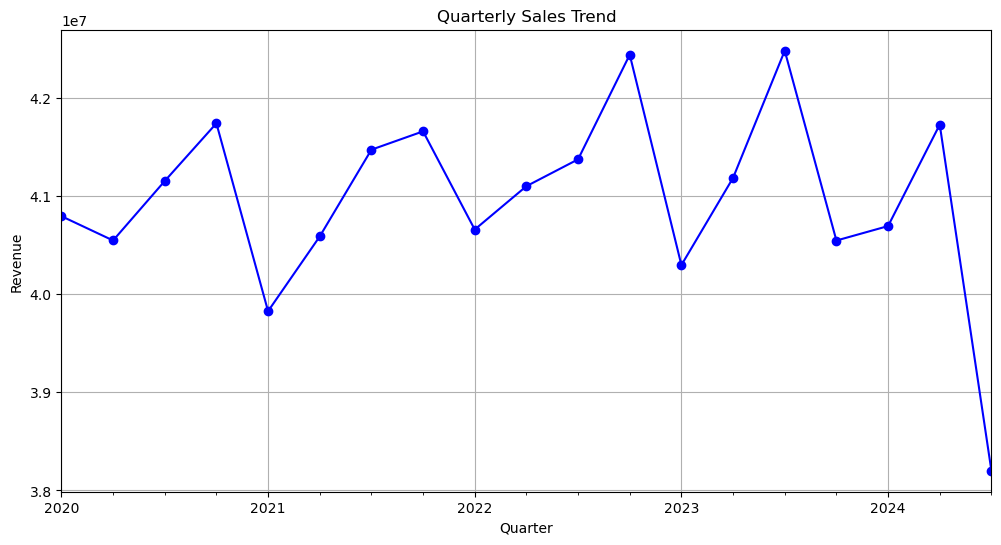

In [47]:
quarterly_trend = df.groupby('Quarter')['Total_Revenue'].sum()

plt.figure(figsize=(12, 6))
quarterly_trend.plot(kind='line', marker='o', color='blue')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

# Question 3. Which store locations generate the highest revenue and profit margins?

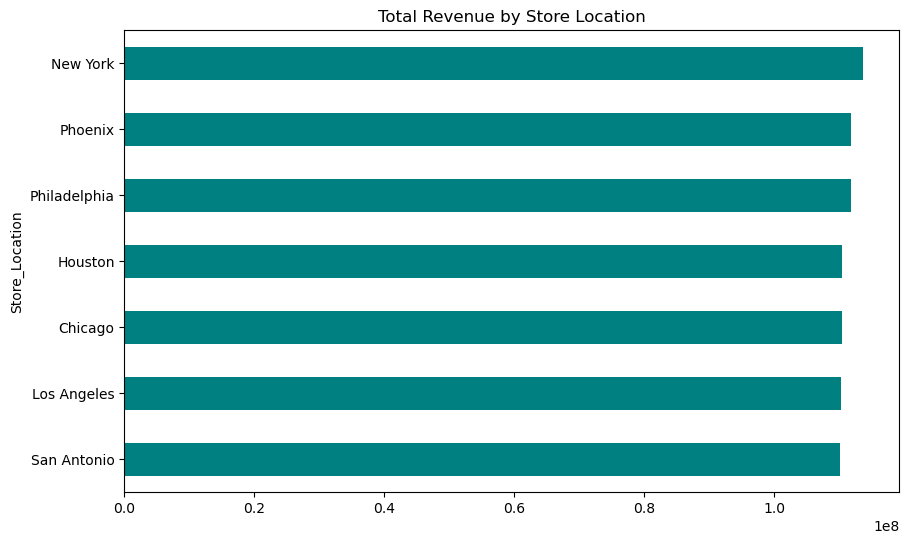

In [49]:
store_revenue = df.groupby('Store_Location')['Total_Revenue'].sum().sort_values()

plt.figure(figsize=(10, 6))
store_revenue.plot(kind='barh', color='teal')
plt.title('Total Revenue by Store Location')
plt.show()

# Question 4. Who are the top performing salespeople by revenue and units sold?

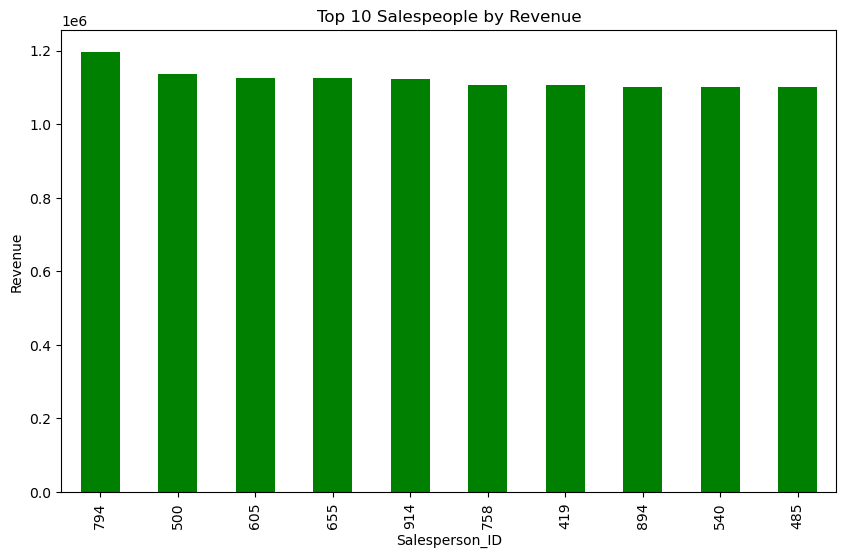

In [51]:
top_salespeople = df.groupby('Salesperson_ID')['Total_Revenue'].sum().nlargest(10)

plt.figure(figsize=(10, 6))
top_salespeople.plot(kind='bar', color='green')
plt.title('Top 10 Salespeople by Revenue')
plt.ylabel('Revenue')
plt.show()

# Question 5. What is the customer demographic profile (age and gender distribution)?

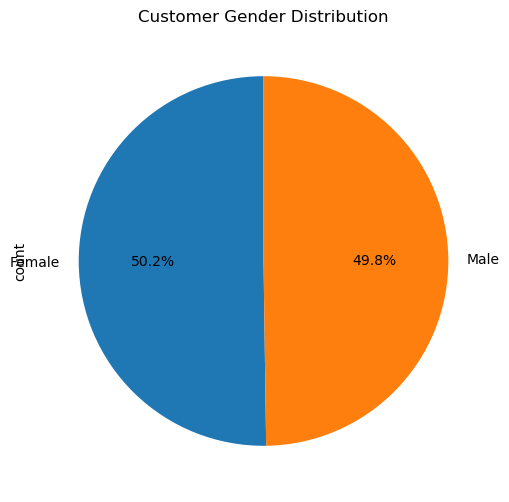

In [52]:
plt.figure(figsize=(6, 6))
df['Customer_Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Customer Gender Distribution')
plt.show()

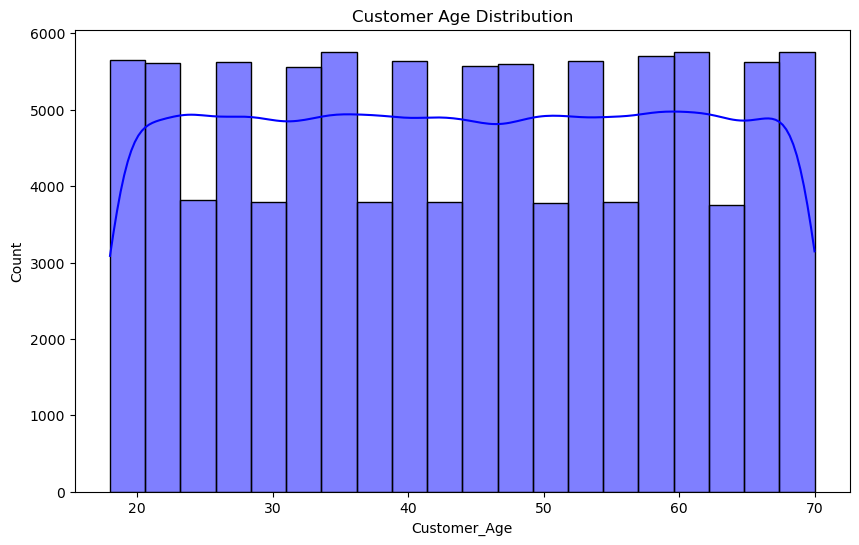

In [56]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Customer_Age'], bins=20, kde=True, color='blue')
plt.title('Customer Age Distribution')
plt.show()

# Question 6. Which age groups spend the most on bikes?

In [57]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels)

C:\Users\Admin\AppData\Local\Temp\ipykernel_22552\3097545401.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_revenue = df.groupby('Age_Group')['Total_Revenue'].sum()


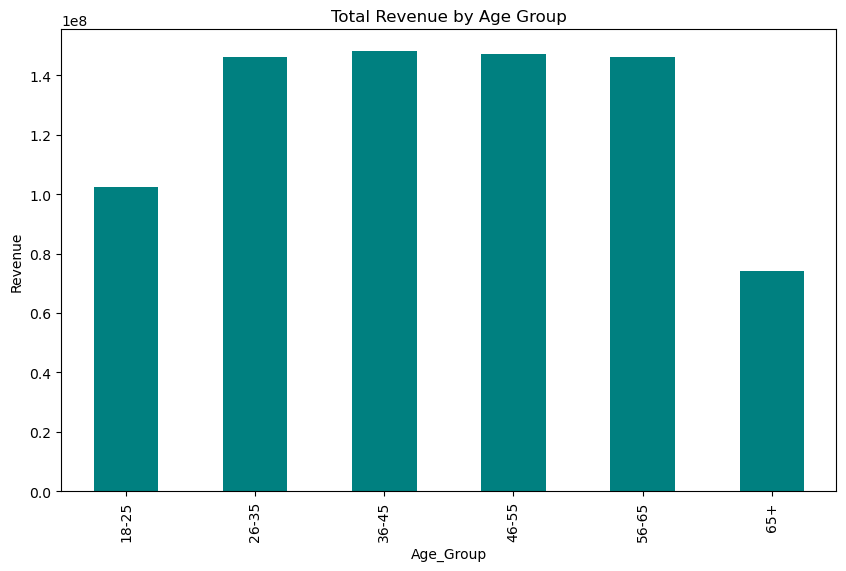

In [58]:
age_group_revenue = df.groupby('Age_Group')['Total_Revenue'].sum()

plt.figure(figsize=(10, 6))
age_group_revenue.plot(kind='bar', color='teal')
plt.title('Total Revenue by Age Group')
plt.ylabel('Revenue')
plt.show()

# Question 7. Are there gender-based preferences for specific bike models?

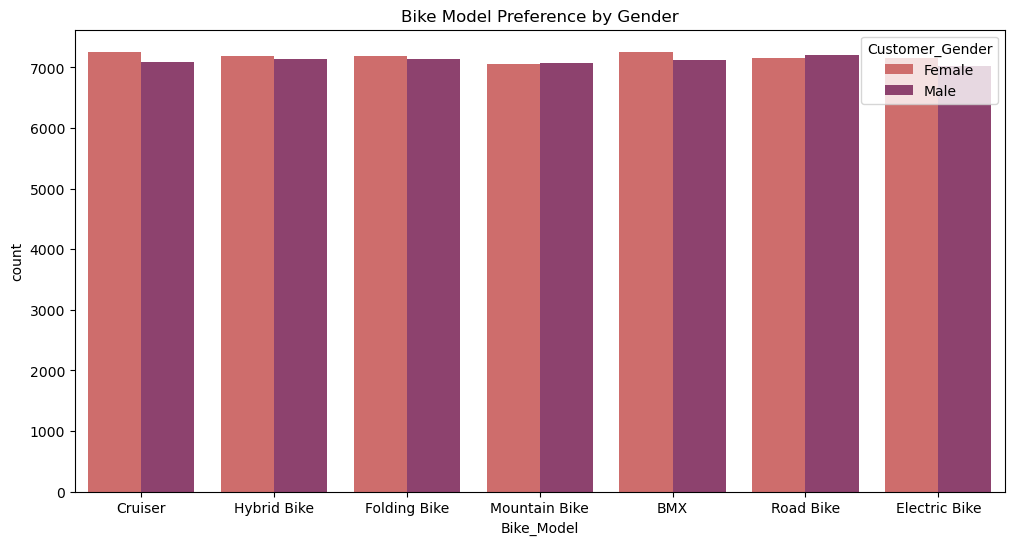

In [60]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Bike_Model', hue='Customer_Gender', palette='flare')
plt.title('Bike Model Preference by Gender')
plt.show()

# Question 8. What is the preferred payment method and does it vary by customer demographics or purchase amount?

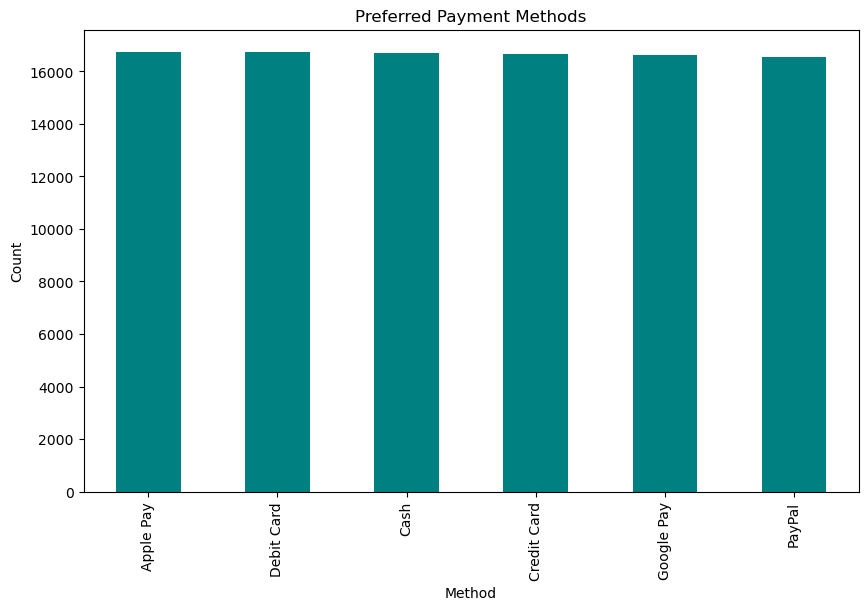

In [61]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure(figsize=(10, 6))
payment_counts.plot(kind='bar', color='teal')
plt.title('Preferred Payment Methods')
plt.xlabel('Method')
plt.ylabel('Count')
plt.show()

# Question 9. What is the average transaction value and how does it vary across stores?

C:\Users\Admin\AppData\Local\Temp\ipykernel_22552\709492066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Store_Location', y='Total_Revenue', palette='viridis')


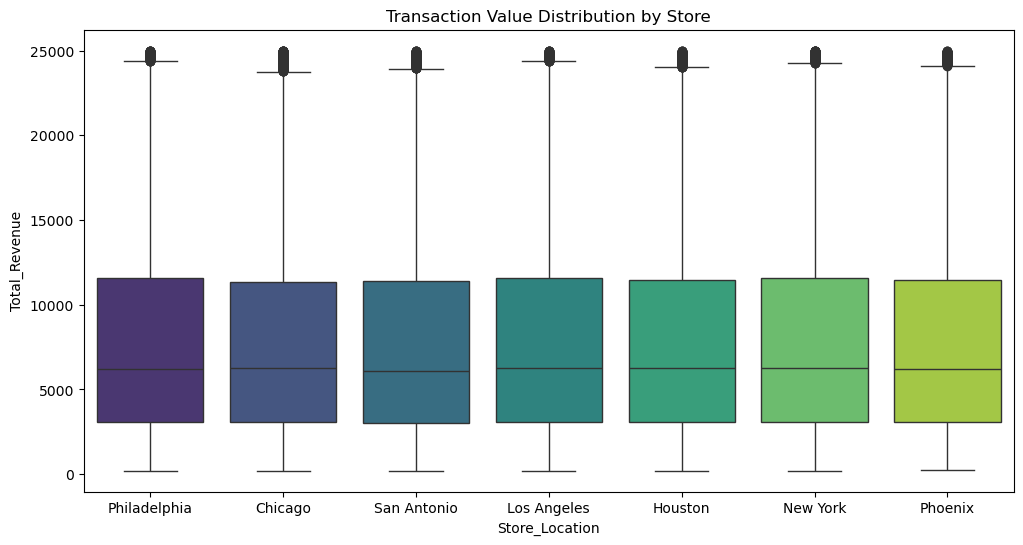

In [63]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Store_Location', y='Total_Revenue', palette='viridis')
plt.title('Transaction Value Distribution by Store')
plt.show()

# Question 10. Are there correlations between customer age, bike model preference, and price point?

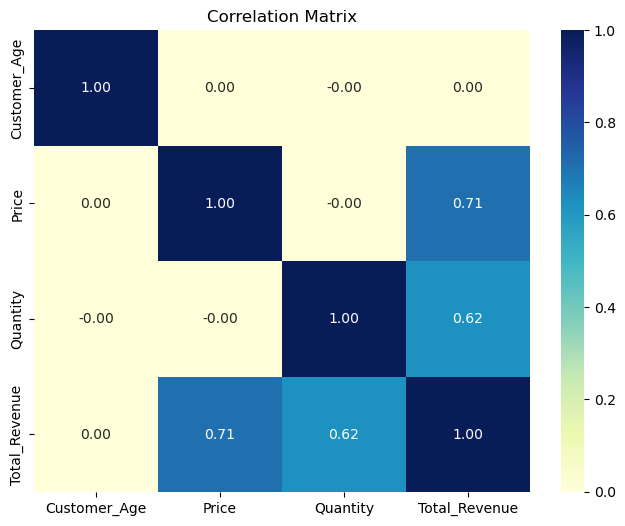

In [66]:
numerical_cols = ['Customer_Age', 'Price', 'Quantity', 'Total_Revenue']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22552\1972376092.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Bike_Model', y='Customer_Age', palette='viridis')


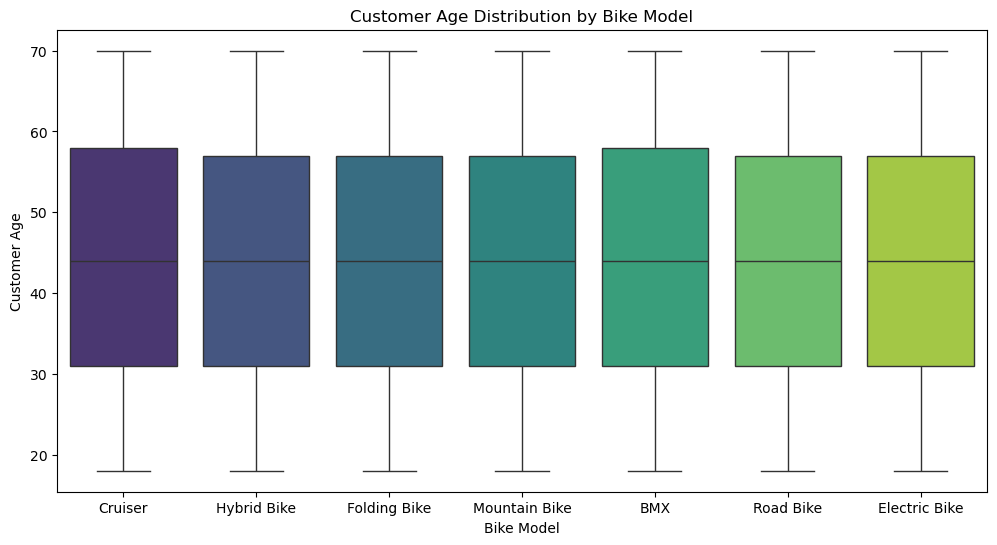

In [65]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Bike_Model', y='Customer_Age', palette='viridis')
plt.title('Customer Age Distribution by Bike Model')
plt.xlabel('Bike Model')
plt.ylabel('Customer Age')
plt.show()